# Practical Session 01c &mdash; Exploratory data analysis & cleaning

**Companion to Lecture&nbsp;01.** Notebooks 01a/01b showed how data becomes arrays *assuming it
is already tidy*. Real data almost never is. As the lecture's workflow slide put it, **most of
the effort in an ML project is getting and cleaning the data, not the algorithm.**

This notebook walks the two steps that come before any model:

1. **Exploratory Data Analysis (EDA)** &mdash; look at the data to understand it and to *find*
   problems.
2. **Cleaning & handling** &mdash; fix those problems, and set the data up so no information leaks
   from the future/test into training.

We use the *same* apartments table as 01a, but this time in its **messy** form &mdash; the same
realistic problems you meet in the wild: missing values, duplicates, typos, wrong dtypes, and
inconsistent category spellings.

> ⭐ **Key idea.** You cannot trust a model you built on data you never looked at. EDA is how
> you earn that trust; cleaning is how you make the data deserve it.

*Run each cell (Shift+Enter). Self-contained and offline (an optional real-data section at
the end needs internet).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_apartments, basic_clean

use_style("notes")
pd.set_option("display.precision", 2)
pd.set_option("display.max_columns", 20)

raw = make_apartments(n=400, seed=0, messy=True)   # the SAME data as 01a, but messy
print("loaded messy apartments table:", raw.shape)

loaded messy apartments table: (405, 9)


## 1. First look: shape, types, summaries

Three commands give a fast, honest first picture: `.head()` / `.sample()` to eyeball rows,
`.info()` for dtypes and non-null counts, and `.describe()` for numeric summaries.

In [2]:
raw.head()

,area_m2,rooms,bathrooms,floor,building_age,neighborhood,has_elevator,dist_center_km,rent_eur
0,85.3,3,2,0,20.0,Norte,True,4.26,1218.0
1,25.0,2,1,1,5.0,Centro,False,5.72,474.0
2,64.1,2,1,0,58.0,Centro,False,6.81,250.0
3,57.5,1,1,0,0.0,Sur,False,3.19,379.0
4,74.7,3,2,3,0.0,Norte,True,0.47,1518.0


In [3]:
raw.info()      # dtypes + non-null counts: already two red flags visible

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_m2         381 non-null    float64
 1   rooms           405 non-null    object 
 2   bathrooms       405 non-null    int64  
 3   floor           405 non-null    int64  
 4   building_age    373 non-null    float64
 5   neighborhood    405 non-null    object 
 6   has_elevator    405 non-null    bool   
 7   dist_center_km  385 non-null    float64
 8   rent_eur        405 non-null    float64
dtypes: bool(1), float64(4), int64(2), object(2)
memory usage: 25.8+ KB


Read `.info()` carefully &mdash; it already reveals two problems:

* **`rooms` is `object`**, not an integer. A numeric column stored as text ⇒ some values are
  strings.
* several columns have **fewer non-null values than 405 rows** ⇒ **missing values**.

In [4]:
# numeric summary: watch the min/max for impossible values
raw.describe().round(1)

,area_m2,bathrooms,floor,building_age,dist_center_km,rent_eur
count,381.0,405.0,405.0,373.0,385.0,405.0
mean,85.1,1.4,5.6,43.5,3.9,990.0
std,202.5,0.6,3.6,55.2,2.3,432.3
min,25.0,1.0,0.0,0.0,-3.0,250.0
25%,58.4,1.0,2.0,22.0,2.3,673.0
50%,74.0,1.0,6.0,40.0,3.6,993.0
75%,91.0,2.0,9.0,63.0,5.5,1231.0
max,4000.0,3.0,11.0,999.0,10.3,2427.0


In [5]:
# non-numeric summary: watch 'unique' for messy categories
raw.describe(include="object")

,rooms,neighborhood
count,405,405
unique,11,10
top,2,Centro
freq,88,117


> ⚠️ **Red flags already.** `area_m2` has a **max of 4000** (a 4000&nbsp;m&sup2; apartment?),
> `building_age` a **max of 999**, `dist_center_km` a **min of &minus;3** (negative distance!),
> and `neighborhood` reports far **more than 5 unique values** even though there are only five
> real neighborhoods. EDA turns "the data looks fine" into a concrete to-fix list.

## 2. Univariate EDA: one column at a time

### Numeric columns &mdash; distributions
Histograms show the shape of each feature and make outliers jump out.

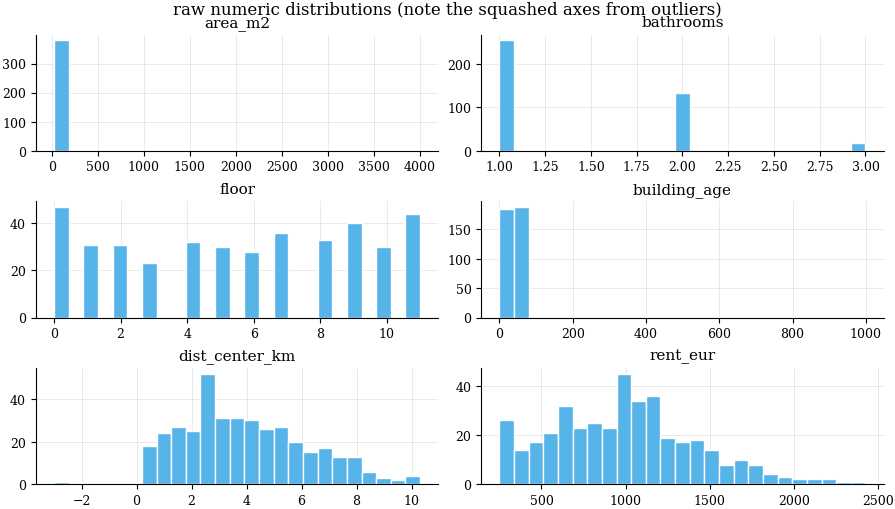

In [6]:
num = ["area_m2", "bathrooms", "floor", "building_age", "dist_center_km", "rent_eur"]
axes = raw[num].hist(figsize=(9, 5), bins=25, color="#56B4E9", edgecolor="white")
for ax in axes.ravel():
    ax.grid(alpha=0.3)
plt.suptitle("raw numeric distributions (note the squashed axes from outliers)", y=1.02)
plt.show()

The `area_m2` and `building_age` histograms are almost empty except for a bar at the far
right: a single **outlier** (4000&nbsp;m&sup2;, age&nbsp;999) stretches the axis and hides the
real distribution. Outliers do not just look bad &mdash; they *distort every summary and many
models*.

### Categorical column &mdash; value counts

In [7]:
print("neighborhood value counts (raw):")
print(raw["neighborhood"].value_counts())

neighborhood value counts (raw):
neighborhood
Centro     117
Norte       69
Oeste       56
Sur         54
Este        48
centro      21
NORTE       19
oeste        8
 Este        7
sur          6
Name: count, dtype: int64


There they are: `centro `, `NORTE`, `sur`, ` Este`, `oeste` are the **same** neighborhoods as
`Centro`, `Norte`, &hellip; typed inconsistently (case + stray spaces). Grouped statistics would
split each neighborhood into several &mdash; a silent, serious bug.

## 3. Cataloguing the problems

Before touching anything, enumerate every issue explicitly. There are five here.

### Missing values

missing values per column:
area_m2           24
building_age      32
dist_center_km    20
dtype: int64


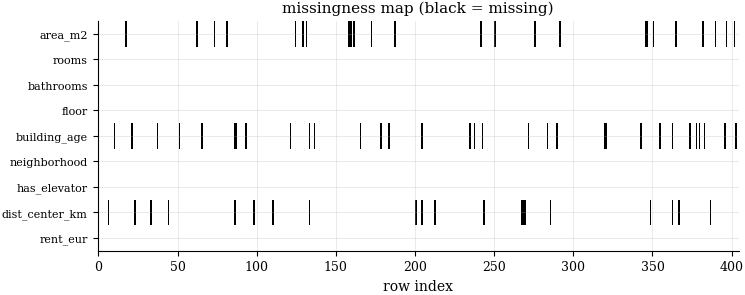

In [8]:
miss = raw.isna().sum()
print("missing values per column:")
print(miss[miss > 0])

fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.imshow(raw.isna().T, aspect="auto", cmap="Greys", interpolation="none")
ax.set_yticks(range(raw.shape[1])); ax.set_yticklabels(raw.columns, fontsize=8)
ax.set_xlabel("row index"); ax.set_title("missingness map (black = missing)")
plt.show()

In [9]:
# Duplicates
print("exact duplicate rows:", raw.duplicated().sum())
raw[raw.duplicated(keep=False)].sort_values(list(raw.columns)).head(6)

exact duplicate rows: 5


,area_m2,rooms,bathrooms,floor,building_age,neighborhood,has_elevator,dist_center_km,rent_eur
173,42.9,1,1,11,68.0,Centro,True,5.88,355.0
327,42.9,1,1,11,68.0,Centro,True,5.88,355.0
160,65.4,2,1,11,37.0,centro,True,1.56,1269.0
219,65.4,2,1,11,37.0,centro,True,1.56,1269.0
245,80.9,4,2,11,31.0,Centro,True,4.14,1495.0
293,80.9,4,2,11,31.0,Centro,True,4.14,1495.0


So the five problems are:

1. **Wrong dtype** &mdash; `rooms` stored as text.
2. **Inconsistent categories** &mdash; `neighborhood` spellings.
3. **Impossible values / typos** &mdash; `area_m2` = 4000, `building_age` = 999, `dist_center_km` < 0.
4. **Missing values** &mdash; in `area_m2`, `building_age`, `dist_center_km`.
5. **Duplicate rows**.

> 🔬 **Going deeper (why values go missing).** The *mechanism* matters. **MCAR** (missing
> completely at random) is harmless to drop; **MAR** (missingness depends on other observed
> columns) can be imputed from them; **MNAR** (depends on the missing value itself, e.g. high
> earners hiding income) can bias the model no matter what you do. Always ask *why* a value is
> missing, not just *how many*.

## 4. Cleaning, step by step

We fix the **structural** problems first (dtypes, categories, impossible values, duplicates),
then discuss missing values and outliers.

### 4.1 Fix dtypes

In [10]:
df = raw.copy()
df["rooms"] = pd.to_numeric(df["rooms"], errors="coerce")   # strings "3" -> 3; junk -> NaN
print("rooms dtype:", df["rooms"].dtype)

rooms dtype: int64


### 4.2 Standardize category spellings
`str.strip()` removes stray spaces, `str.title()` normalizes case &mdash; collapsing the ten raw
spellings back to five.

In [11]:
df["neighborhood"] = df["neighborhood"].astype(str).str.strip().str.title()
print("clean neighborhoods:", sorted(df["neighborhood"].unique()))
print(df["neighborhood"].value_counts())

clean neighborhoods: ['Centro', 'Este', 'Norte', 'Oeste', 'Sur']
neighborhood
Centro    138
Norte      88
Oeste      64
Sur        60
Este       55
Name: count, dtype: int64


### 4.3 Turn impossible values into missing
A negative distance or a 999-year-old building is not an outlier to keep &mdash; it is bad data.
Replace with `NaN` (to be imputed) rather than a fake number.

In [12]:
before = df[["area_m2", "building_age", "dist_center_km"]].describe().loc[["min", "max"]]
df.loc[df["building_age"] > 120, "building_age"] = np.nan
df.loc[df["area_m2"] > 500, "area_m2"] = np.nan
df.loc[df["dist_center_km"] < 0, "dist_center_km"] = np.nan
after = df[["area_m2", "building_age", "dist_center_km"]].describe().loc[["min", "max"]]
print("min/max BEFORE:\n", before.round(1), "\n\nmin/max AFTER:\n", after.round(1))

min/max BEFORE:
      area_m2  building_age  dist_center_km
min     25.0           0.0            -3.0
max   4000.0         999.0            10.3 

min/max AFTER:
      area_m2  building_age  dist_center_km
min     25.0           0.0             0.2
max    151.7          79.0            10.3


### 4.4 Drop duplicate rows

In [13]:
n0 = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"dropped {n0 - len(df)} duplicate rows -> {len(df)} rows remain")

dropped 5 duplicate rows -> 400 rows remain


The structural fixes above are exactly what `nb_data.basic_clean()` packages up (so the
pipeline notebook 01e can reuse them in one line). Let's confirm ours matches:

In [14]:
assert basic_clean(raw).shape == df.shape
print("basic_clean() reproduces our manual cleaning:", basic_clean(raw).shape)

basic_clean() reproduces our manual cleaning: (400, 9)


### 4.5 Now the distributions are readable
With the impossible values gone, the histograms finally show the real shapes.

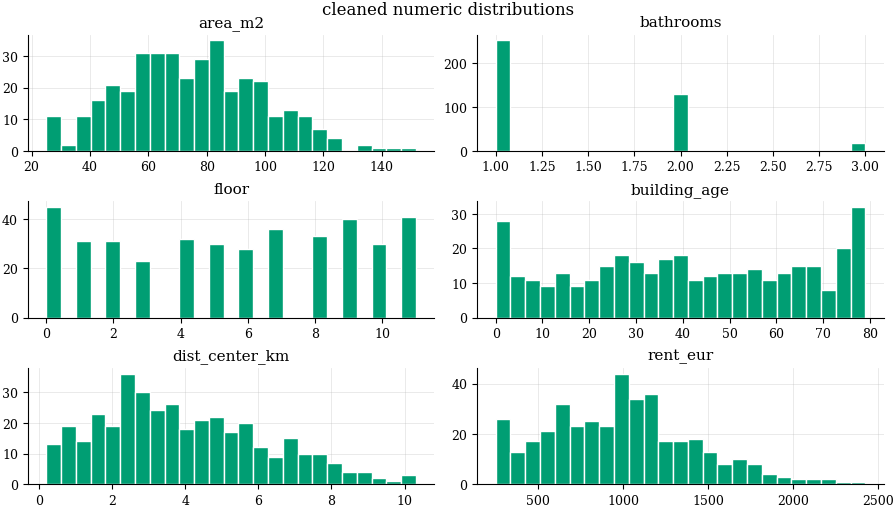

In [15]:
axes = df[num].hist(figsize=(9, 5), bins=25, color="#009E73", edgecolor="white")
for ax in axes.ravel(): ax.grid(alpha=0.3)
plt.suptitle("cleaned numeric distributions", y=1.02)
plt.show()

## 5. Missing values and outliers: what to actually do

### 5.1 Missing values &mdash; drop vs impute
Two broad options:

* **Drop** rows (or a column) &mdash; fine when very few rows are affected, wasteful otherwise.
* **Impute** &mdash; fill with a sensible estimate: the **median** for skewed numeric columns, the
  **mode** for categoricals. Optionally add a *missing-indicator* column so the model can tell.

In [16]:
print("remaining missing after structural cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])

# illustrative median imputation (see the caveat below before doing this for real!)
med = df["building_age"].median()
demo = df["building_age"].fillna(med)
print(f"\nmedian building_age = {med:.0f}; filled {df['building_age'].isna().sum()} gaps")

remaining missing after structural cleaning:
area_m2           25
building_age      33
dist_center_km    21
dtype: int64

median building_age = 40; filled 33 gaps


> ⚠️ **Watch out (leakage).** The median above was computed from the **whole** table. If you
> impute like this *before* splitting, the training set has secretly seen the test set's
> statistics. The correct place to impute is **inside a Pipeline**, fitted on the training
> split only &mdash; which is exactly what 01e does. Here we impute only to *look* at the data.

### 5.2 Outliers &mdash; detect, then decide
Not every extreme value is an error. The **IQR rule** flags points outside
$[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$. Whether to cap, drop, or keep them is a
*modelling decision*, not automatic.

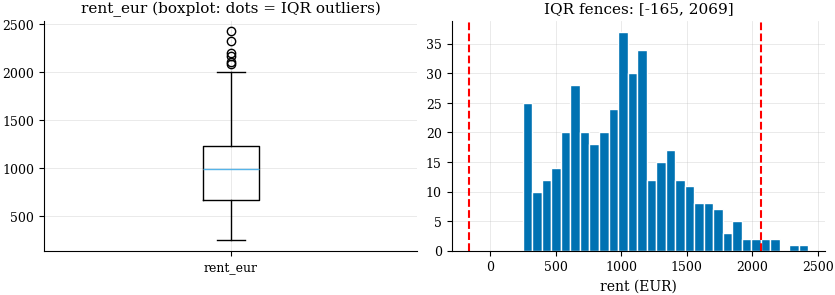

rent values flagged by the IQR rule: 6


In [17]:
def iqr_fences(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.0))
df.boxplot(column="rent_eur", ax=ax[0]); ax[0].set_title("rent_eur (boxplot: dots = IQR outliers)")
lo, hi = iqr_fences(df["rent_eur"].dropna())
ax[1].hist(df["rent_eur"].dropna(), bins=30, color="#0072B2", edgecolor="white")
ax[1].axvline(lo, color="r", ls="--"); ax[1].axvline(hi, color="r", ls="--")
ax[1].set_title(f"IQR fences: [{lo:.0f}, {hi:.0f}]"); ax[1].set_xlabel("rent (EUR)")
for a in ax: a.grid(alpha=0.3)
plt.show()
print(f"rent values flagged by the IQR rule: {((df.rent_eur < lo) | (df.rent_eur > hi)).sum()}")

## 6. Bivariate EDA on the clean data: what predicts rent?

Now that the table is trustworthy, look at **relationships** with the target &mdash; the signal a
model will exploit.

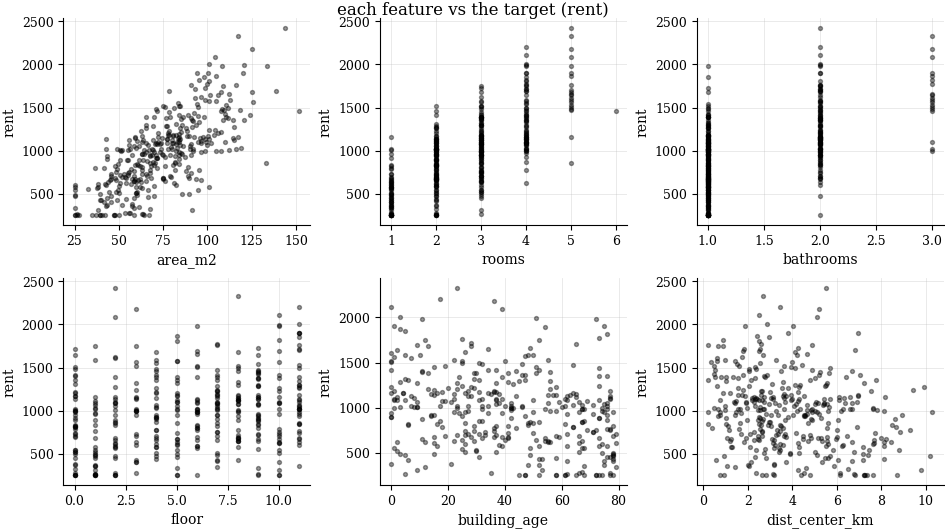

In [18]:
feat = ["area_m2", "rooms", "bathrooms", "floor", "building_age", "dist_center_km"]
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.2))
for ax, c in zip(axes.ravel(), feat):
    ax.scatter(df[c], df["rent_eur"], s=8, alpha=0.4)
    ax.set_xlabel(c); ax.set_ylabel("rent")
    ax.grid(alpha=0.3)
plt.suptitle("each feature vs the target (rent)", y=1.02)
plt.show()

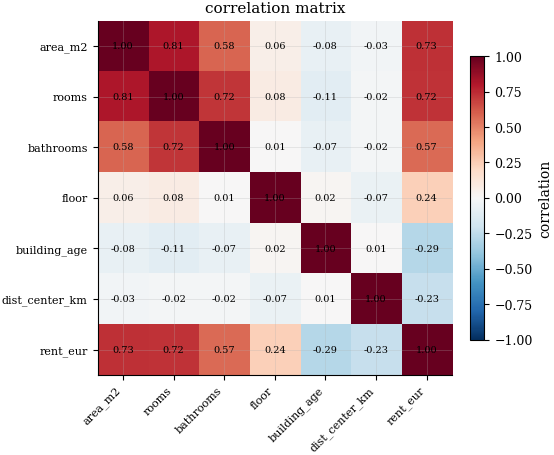

In [19]:
# correlation heatmap (numeric columns)
corr = df[feat + ["rent_eur"]].corr()
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("correlation matrix")
plt.show()

In [20]:
# grouped statistic on the CLEANED categories (would have been wrong on the raw spellings!)
df.groupby("neighborhood")["rent_eur"].agg(["mean", "median", "count"]).round(0)

,mean,median,count
neighborhood,,,
Centro,1140.0,1098.0,135
Este,892.0,864.0,54
Norte,984.0,1017.0,87
Oeste,936.0,944.0,64
Sur,802.0,770.0,60


## 7. Data handling: split first, transform second

The single most important habit in applied ML: **decide the train/validation/test split
before you fit anything that learns from the data** (a scaler's mean, an imputer's median, an
encoder's categories). Otherwise those statistics leak test information into training and your
scores become optimistic lies.

In [21]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=0)

leaky = df["building_age"].mean()          # WRONG: uses all rows
honest = train["building_age"].mean()      # RIGHT: training rows only
print(f"median/mean imputation value computed on ALL data : {leaky:.2f}  (leaks the test set)")
print(f"...computed on the TRAIN split only               : {honest:.2f}  (correct)")
print("\nThey differ -> the leaky version secretly used test information.")

median/mean imputation value computed on ALL data : 40.87  (leaks the test set)
...computed on the TRAIN split only               : 39.70  (correct)

They differ -> the leaky version secretly used test information.


> ⭐ **Key idea.** *Fit transforms on train, apply to test.* Doing this by hand is error-prone,
> so scikit-learn bundles the split-safe transforms and the model into a single **`Pipeline`**
> &mdash; the subject of notebook **01e**.

## 8. Optional: a real messy dataset (Titanic)

Everything above transfers directly to real data. The Titanic passenger table is a classic
teaching example with genuine missing values (many `age`s, most `cabin`s). This cell needs
**internet**; it skips cleanly if offline.

In [25]:
# Only the DOWNLOAD is guarded, so a real bug below is not mislabelled "no internet".
tit = None
try:
    from sklearn.datasets import fetch_openml
    tit = fetch_openml("titanic", version=1, as_frame=True, parser="auto").frame
except Exception as e:
    print("skipped (could not download the dataset):", type(e).__name__)

if tit is not None:
    print("Titanic:", tit.shape)
    print()
    print("missing values (top 5):")
    print(tit.isna().sum().sort_values(ascending=False).head(5))
    # OpenML returns 'survived' (and 'sex') as *categorical* columns; make the target
    # numeric before averaging, and pass observed=True for the categorical group key.
    tit["survived"] = pd.to_numeric(tit["survived"])
    print()
    print("survival rate by sex (a strong, real signal):")
    print(tit.groupby("sex", observed=True)["survived"].mean().round(3))

Titanic: (1309, 14)

missing values (top 5):
body         1188
cabin        1014
boat          823
home.dest     564
age           263
dtype: int64

survival rate by sex (a strong, real signal):
sex
female    0.73
male      0.19
Name: survived, dtype: float64


## Recap & exercises

**Recap.**
* **EDA first:** `.info()`, `.describe()`, histograms, value counts and a missingness map turn
  "looks fine" into a concrete list of problems.
* **Clean structurally:** fix dtypes, standardize categories, turn impossible values into
  `NaN`, drop duplicates. (Packaged as `nb_data.basic_clean`.)
* **Missing values:** drop when rare, else impute (median/mode) &mdash; but *inside a pipeline,
  fitted on train only*.
* **Outliers:** detect (IQR/boxplot), then *decide* &mdash; keeping is a valid choice.
* **Split before you transform.** Anything that learns statistics from data must see only the
  training split, or you leak.

**Exercises.**
1. Re-run with `make_apartments(seed=1, messy=True)`. Do the same five problem types appear?
2. Impute `dist_center_km` with the median vs the mean. When would they differ a lot?
3. Add a boolean column `area_was_missing = raw["area_m2"].isna()` *before* imputing. Why can a
   missing-indicator help a model?
4. Flag `rent_eur` outliers with the IQR rule *and* a z-score rule (`|z| > 3`). Do they agree?
5. In the Titanic cell, drop the `cabin` column (mostly missing) and impute `age` with the
   median; how many rows survive a `dropna()` instead?

*Next:* **01d &mdash; train / validation / test**, the discipline of honest evaluation (and *why* you
need a validation set), followed by **01e &mdash; the first end-to-end ML pipeline**.